In [14]:
# Part - B
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df = pd.read_csv("House_Price_Dataset.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(3800, 12)

First 5 Rows:
   property_id   sale_date  area_sqft  bedrooms  bathrooms  location_score  \
0       200001  01-01-2014       2181         6          4             8.1   
1       200002  01-12-2019       2383         5          4             5.3   
2       200003  01-10-2016       1047         3          3             5.9   
3       200004  01-03-2013       1753         4          3             7.0   
4       200005  01-07-2013       1728         4          4            10.0   

   property_age  distance_city_km  near_school  near_metro  crime_rate_index  \
0            21               3.8            0           0              4.84   
1            28              10.9            1           1              2.89   
2             7              27.5            0           1              4.04   
3            27              12.1            0           0              3.28   
4            32               1.4            0           1              3.84   

   house_

In [15]:
# Data Types
print("\nData Types:")
print(df.dtypes)


#  Check Missing Value

print("\nMissing Values:")
print(df.isnull().sum())

# 4. Convert Sale_Date

df["sale_date"] = pd.to_datetime(
    df["sale_date"],
    format="%d-%m-%Y"
)

#  Create Useful Date Features

df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month

# 6. Identify Traget Variable And Features

# Target variable
y = df["house_price_inr"]


# Features
X = df[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "property_age",
        "distance_city_km",
        "near_school",
        "near_metro",
        "crime_rate_index",
        "sale_year",
        "sale_month"
    ]
]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("house_price_inr")

#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTrain-Test Split:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# 8. Basic PreProcessing - Featuer Scaling

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)


# Convert scaled arrays back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("\nScaled Training Data:")
print(X_train_scaled.head())

print("\nScaled Testing Data:")
print(X_test_scaled.head())





Data Types:
property_id           int64
sale_date            object
area_sqft             int64
bedrooms              int64
bathrooms             int64
location_score      float64
property_age          int64
distance_city_km    float64
near_school           int64
near_metro            int64
crime_rate_index    float64
house_price_inr       int64
dtype: object

Missing Values:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

Features:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'sale_year', 'sale_month']

Target Variable:
house_price_inr

Train-Test Split:
X_train shape: (3040, 11)
X_test shape : (760, 11)
y_train shape: (3040,)
y_test shape : (760,)

Scaled Traini

 
 Ridge Regression (L2) 
Alpha: 1.0
Training RMSE: 2482398.5783949867
Testing RMSE: 2539952.396526343
Testing R2: 0.9198939018648887
 
 Lasso Regression (L1) 
Alpha: 1.0
Training RMSE: 2482394.781308313
Testing RMSE: 2539709.13488088
Testing R2: 0.9199092453084179
 
 Alpha Tuning 
Best Ridge Alpha: 1.151395399326447
Best Lasso Alpha: 1000.0
 
 Ridge VS Lasso Comparison 
Model  Best_Alpha  Training_RMSE  Validation_RMSE    Test_RMSE  Test_R2
Ridge    1.151395   2.482400e+06     2.495253e+06 2.539990e+06 0.919892
Lasso 1000.000000   2.482396e+06     2.495236e+06 2.539903e+06 0.919897
 
 Feaure Coefficient Behavior 
         Feature  Ridge_Coefficient  Lasso_Coefficient
       area_sqft       6.947542e+06       6.955327e+06
        bedrooms       2.962262e+05       2.891152e+05
       bathrooms       2.730611e+05       2.726389e+05
  location_score       3.678386e+06       3.680271e+06
    property_age      -6.499152e+05      -6.492142e+05
distance_city_km      -2.872869e+04      -2.6496

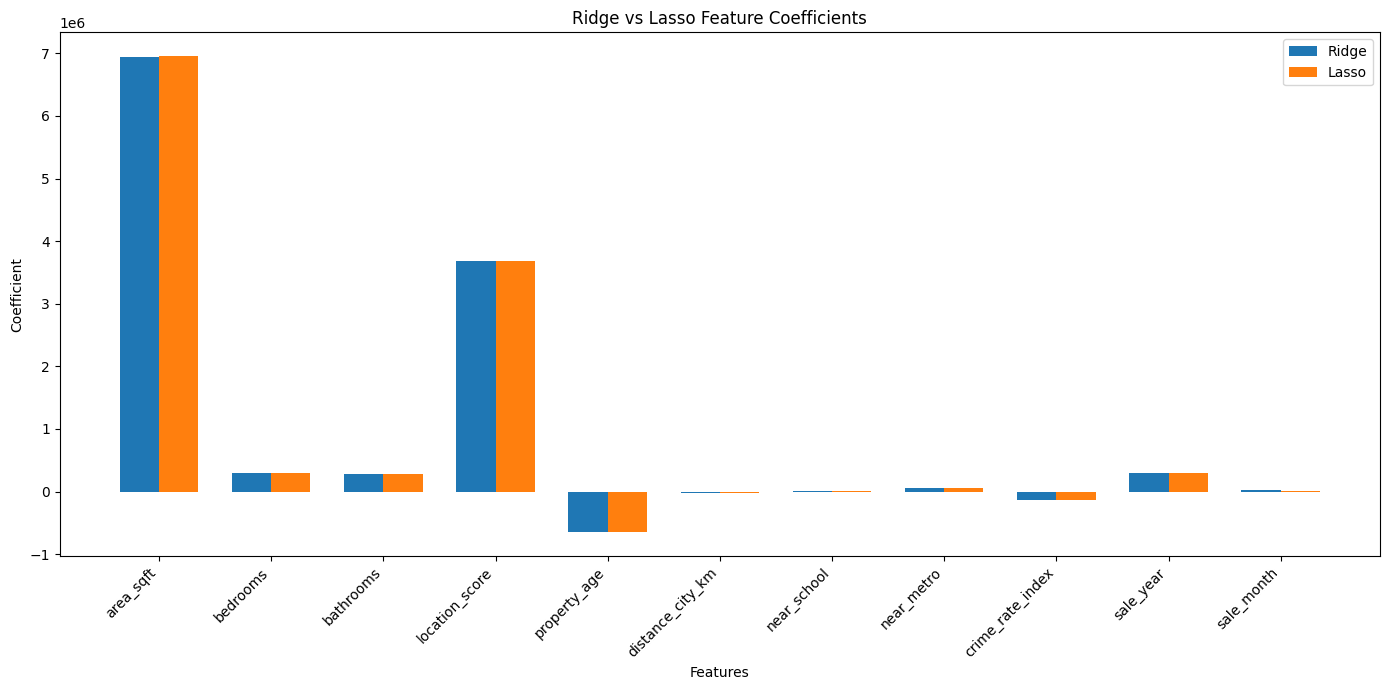

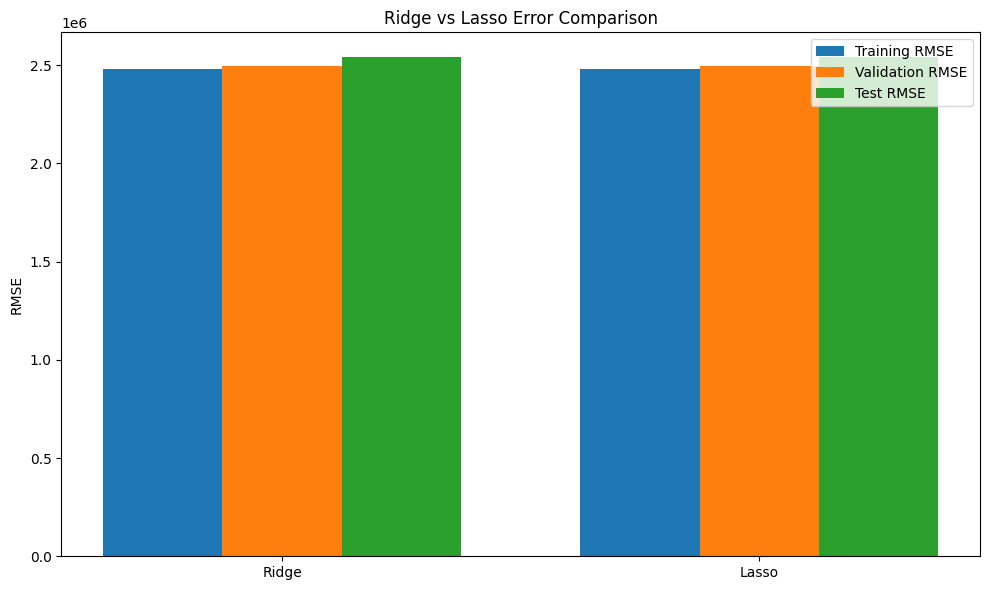

Task 9  -> Ridge Regression (L2)       DONE
Task 10 -> Lasso Regression (L1)       DONE
Task 11 -> Alpha Cross-Validation      DONE
Task 12 -> Ridge vs Lasso Comparison   DONE


In [16]:
# Part - C

#  Ridge Regression (L2)

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_train_pred = ridge.predict(X_train_scaled)

ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_rmse = np.sqrt(
    mean_squared_error(y_train, ridge_train_pred)
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_test_pred)
)

ridge_test_r2 = r2_score(
    y_test,
    ridge_test_pred
)


print(" \n Ridge Regression (L2) ")


print("Alpha:", ridge.alpha)

print("Training RMSE:", ridge_train_rmse)

print("Testing RMSE:", ridge_test_rmse)

print("Testing R2:", ridge_test_r2)


#  Lasso Regression (L1)

lasso = Lasso(
    alpha=1.0,
    max_iter=100000
)

lasso.fit(
    X_train_scaled,
    y_train
)

lasso_train_pred = lasso.predict(X_train_scaled)

lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_rmse = np.sqrt(
    mean_squared_error(y_train, lasso_train_pred)
)

lasso_test_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_test_pred)
)

lasso_test_r2 = r2_score(
    y_test,
    lasso_test_pred
)



print(" \n Lasso Regression (L1) ")

print("Alpha:", lasso.alpha)

print("Training RMSE:", lasso_train_rmse)

print("Testing RMSE:", lasso_test_rmse)

print("Testing R2:", lasso_test_r2)

#  Cross-Validation


alphas = np.logspace(-3, 3, 50)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Ridge Cross Validation

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=cv,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(
    X_train_scaled,
    y_train
)

best_ridge_alpha = ridge_cv.alpha_

# Lasso Cross Validation

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv,
    max_iter=100000,
    random_state=42
)

lasso_cv.fit(
    X_train_scaled,
    y_train
)

best_lasso_alpha = lasso_cv.alpha_



print(" \n Alpha Tuning ")

print("Best Ridge Alpha:", best_ridge_alpha)

print("Best Lasso Alpha:", best_lasso_alpha)

# Train Final Ridge

ridge_final = Ridge(
    alpha=best_ridge_alpha
)

ridge_final.fit(
    X_train_scaled,
    y_train
)

ridge_train_pred = ridge_final.predict(
    X_train_scaled
)

ridge_test_pred = ridge_final.predict(
    X_test_scaled
)

# Train Final Lasso

lasso_final = Lasso(
    alpha=best_lasso_alpha,
    max_iter=100000
)

lasso_final.fit(
    X_train_scaled,
    y_train
)

lasso_train_pred = lasso_final.predict(
    X_train_scaled
)

lasso_test_pred = lasso_final.predict(
    X_test_scaled
)

#  Traning Erorr

ridge_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        ridge_train_pred
    )
)

lasso_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        lasso_train_pred
    )
)


# Validation Erorr  Cross Validation

ridge_scores = cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

lasso_scores = cross_val_score(
    lasso_final,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)


ridge_validation_rmse = -ridge_scores.mean()

lasso_validation_rmse = -lasso_scores.mean()

# Test Erorr

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_test_pred
    )
)

lasso_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_test_pred
    )
)

# R2 Score

ridge_r2 = r2_score(
    y_test,
    ridge_test_pred
)

lasso_r2 = r2_score(
    y_test,
    lasso_test_pred
)


# FEATURE Coefficients
features = X_train.columns
coefficient_table = pd.DataFrame({

    "Feature": features,

    "Ridge_Coefficient": ridge_final.coef_,

    "Lasso_Coefficient": lasso_final.coef_

})

# Comparison Table

comparison = pd.DataFrame({

    "Model": [
        "Ridge",
        "Lasso"
    ],

    "Best_Alpha": [
        best_ridge_alpha,
        best_lasso_alpha
    ],

    "Training_RMSE": [
        ridge_train_rmse,
        lasso_train_rmse
    ],

    "Validation_RMSE": [
        ridge_validation_rmse,
        lasso_validation_rmse
    ],

    "Test_RMSE": [
        ridge_test_rmse,
        lasso_test_rmse
    ],

    "Test_R2": [
        ridge_r2,
        lasso_r2
    ]

})


# Print Results

print(" \n Ridge VS Lasso Comparison ")


print(comparison.to_string(index=False))


print(" \n Feaure Coefficient Behavior ")


print(coefficient_table.to_string(index=False))

# Lasso COEFFICIENTS

lasso_zero = np.sum(
    lasso_final.coef_ == 0
)

ridge_zero = np.sum(
    ridge_final.coef_ == 0
)


print(" \nRidge Zero Coefficients:", ridge_zero)

print(" \nLasso Zero Coefficients:", lasso_zero)


# Find Better Model


if ridge_validation_rmse < lasso_validation_rmse:

    print("\nBetter Model: RIDGE")

else:

    print("\nBetter Model: LASSO")


#  Coefficient Comparison

x = np.arange(len(features))

width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    ridge_final.coef_,
    width,
    label="Ridge"
)

plt.bar(
    x + width / 2,
    lasso_final.coef_,
    width,
    label="Lasso"
)

plt.xticks(
    x,
    features,
    rotation=45,
    ha="right"
)

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.title(
    "Ridge vs Lasso Feature Coefficients"
)

plt.legend()

plt.tight_layout()

plt.show()


# Erorr Comparison

models = ["Ridge", "Lasso"]

training = [
    ridge_train_rmse,
    lasso_train_rmse
]

validation = [
    ridge_validation_rmse,
    lasso_validation_rmse
]

testing = [
    ridge_test_rmse,
    lasso_test_rmse
]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    training,
    width,
    label="Training RMSE"
)

plt.bar(
    x,
    validation,
    width,
    label="Validation RMSE"
)

plt.bar(
    x + width,
    testing,
    width,
    label="Test RMSE"
)

plt.xticks(
    x,
    models
)

plt.ylabel("RMSE")

plt.title(
    "Ridge vs Lasso Error Comparison"
)

plt.legend()

plt.tight_layout()

plt.show()

print("Task 9  -> Ridge Regression (L2)       DONE")

print("Task 10 -> Lasso Regression (L1)       DONE")

print("Task 11 -> Alpha Cross-Validation      DONE")

print("Task 12 -> Ridge vs Lasso Comparison   DONE")

In [17]:
# PART -D
#  Cross-Validation Strategies


import numpy as np
import pandas as pd

from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)


#  K-Fold Cross-Valiadation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kf_rmse = np.sqrt(
    -cross_val_score(
        ridge_final,
        X_train_scaled,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
).mean()

kf_mae = -cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
).mean()

kf_r2 = cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring="r2"
).mean()


#  Stratified K-Fold


y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop"
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

skf_rmse = np.sqrt(
    -cross_val_score(
        ridge_final,
        X_train_scaled,
        y_train,
        cv=skf.split(X_train_scaled, y_bins),
        scoring="neg_mean_squared_error"
    )
).mean()

skf_mae = -cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=skf.split(X_train_scaled, y_bins),
    scoring="neg_mean_absolute_error"
).mean()

skf_r2 = cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=skf.split(X_train_scaled, y_bins),
    scoring="r2"
).mean()


# Leave-One-Out Cross-Validation

loo = LeaveOneOut()

# For large datasets, use a small sample

X_loo = X_train_scaled.iloc[:100]
y_loo = y_train.iloc[:100]

loo_rmse = np.sqrt(
    -cross_val_score(
        ridge_final,
        X_loo,
        y_loo,
        cv=loo,
        scoring="neg_mean_squared_error"
    )
).mean()

loo_mae = -cross_val_score(
    ridge_final,
    X_loo,
    y_loo,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

loo_r2 = np.nan

# 4. Time Series Spilt

tscv = TimeSeriesSplit(
    n_splits=5
)

time_rmse = np.sqrt(
    -cross_val_score(
        ridge_final,
        X_train_scaled,
        y_train,
        cv=tscv,
        scoring="neg_mean_squared_error"
    )
).mean()

time_mae = -cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
).mean()

time_r2 = cross_val_score(
    ridge_final,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring="r2"
).mean()


# Final Comparion

comparison = pd.DataFrame({

    "CV_Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "Leave-One-Out",
        "Time Series Split"
    ],

    "RMSE": [
        kf_rmse,
        skf_rmse,
        loo_rmse,
        time_rmse
    ],

    "MAE": [
        kf_mae,
        skf_mae,
        loo_mae,
        time_mae
    ],

    "R2": [
        kf_r2,
        skf_r2,
        loo_r2,
        time_r2
    ]
})


# Result


print(" \n CV Perfromance Comparison ")


print(
    comparison.to_string(
        index=False
    )
)

# Performance Analiysis

best_rmse = comparison.loc[
    comparison["RMSE"].idxmin()
]

best_mae = comparison.loc[
    comparison["MAE"].idxmin()
]

best_r2 = comparison.loc[
    comparison["R2"].idxmax()
]

print(" \n Parfromance Analysis ")


print(
    "Best RMSE Strategy:",
    best_rmse["CV_Strategy"]
)

print(
    "Best MAE Strategy:",
    best_mae["CV_Strategy"]
)

print(
    "Best R2 Strategy:",
    best_r2["CV_Strategy"]
)

print("Task 13 -> K-Fold Cross-Validation        DONE")
print("Task 13 -> Stratified K-Fold              DONE")
print("Task 13 -> Leave-One-Out                  DONE")
print("Task 13 -> Time Series Split              DONE")
print("Task 14 -> Performance Metrics Analysis   DONE")

 
 CV Perfromance Comparison 
      CV_Strategy         RMSE          MAE       R2
           K-Fold 2.495253e+06 1.907159e+06 0.916306
Stratified K-Fold 2.490951e+06 1.904519e+06 0.916739
    Leave-One-Out 1.881200e+06 1.881200e+06      NaN
Time Series Split 2.518101e+06 1.922226e+06 0.916041
 
 Parfromance Analysis 
Best RMSE Strategy: Leave-One-Out
Best MAE Strategy: Leave-One-Out
Best R2 Strategy: Stratified K-Fold
Task 13 -> K-Fold Cross-Validation        DONE
Task 13 -> Stratified K-Fold              DONE
Task 13 -> Leave-One-Out                  DONE
Task 13 -> Time Series Split              DONE
Task 14 -> Performance Metrics Analysis   DONE


In [18]:
# PART - E

# Tree-Based Regression Models


import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# Decisoon Tree Regression


tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_train_pred = tree.predict(
    X_train
)

tree_test_pred = tree.predict(
    X_test
)

tree_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tree_train_pred
    )
)

tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_test_pred
    )
)

tree_test_mae = mean_absolute_error(
    y_test,
    tree_test_pred
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_pred
)

print(" \n Decisoon Tree Regression ")

print("Training RMSE:", tree_train_rmse)
print("Testing RMSE:", tree_test_rmse)
print("Testing MAE:", tree_test_mae)
print("Testing R2:", tree_test_r2)


#  Control Tree Complexit


tree_control = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree_control.fit(
    X_train,
    y_train
)

control_pred = tree_control.predict(
    X_test
)

control_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        control_pred
    )
)

control_r2 = r2_score(
    y_test,
    control_pred
)


print(" \n Tree Complexity Control ")


print("Max Depth:", 5)
print("Min Samples Split:", 10)
print("Min Samples Leaf:", 5)

print("Test RMSE:", control_rmse)
print("Test R2:", control_r2)


# T Random Forest Regression


forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest.fit(
    X_train,
    y_train
)

forest_train_pred = forest.predict(
    X_train
)

forest_test_pred = forest.predict(
    X_test
)

forest_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        forest_train_pred
    )
)

forest_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_test_pred
    )
)

forest_test_mae = mean_absolute_error(
    y_test,
    forest_test_pred
)

forest_test_r2 = r2_score(
    y_test,
    forest_test_pred
)


print(" \n Random Forest Regression ")


print("Number of Trees:", 100)

print("Training RMSE:", forest_train_rmse)
print("Testing RMSE:", forest_test_rmse)
print("Testing MAE:", forest_test_mae)
print("Testing R2:", forest_test_r2)



#  Decision Tree vs Random

comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Training_RMSE": [
        tree_train_rmse,
        forest_train_rmse
    ],

    "Test_RMSE": [
        tree_test_rmse,
        forest_test_rmse
    ],

    "Test_MAE": [
        tree_test_mae,
        forest_test_mae
    ],

    "Test_R2": [
        tree_test_r2,
        forest_test_r2
    ]
})


print(" \n Tree VS Random Forest ")


print(
    comparison.to_string(
        index=False
    )
)


# Find Best Model


best_model = comparison.loc[
    comparison["Test_RMSE"].idxmin()
]

print(" \n Best Model ")


print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Test RMSE:",
    best_model["Test_RMSE"]
)

print(
    "Test R2:",
    best_model["Test_R2"]
)


# Feature Importance


feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)



print(" \n Random Forest Feature Importance ")


print(
    feature_importance.to_string(
        index=False
    )
)

print("Task 15 -> Decision Tree Regression       DONE")
print("Task 16 -> Tree Complexity Control        DONE")
print("Task 17 -> Random Forest Regression       DONE")
print("Task 18 -> Tree vs Ensemble Comparison    DONE")


 
 Decisoon Tree Regression 
Training RMSE: 0.0
Testing RMSE: 3290411.8468811656
Testing MAE: 2395187.719736842
Testing R2: 0.8655641974314878
 
 Tree Complexity Control 
Max Depth: 5
Min Samples Split: 10
Min Samples Leaf: 5
Test RMSE: 3063631.2537640957
Test R2: 0.8834566744111698
 
 Random Forest Regression 
Number of Trees: 100
Training RMSE: 891554.1062195051
Testing RMSE: 2405401.9213711913
Testing MAE: 1757755.0067894738
Testing R2: 0.9281561279076027
 
 Tree VS Random Forest 
        Model  Training_RMSE    Test_RMSE     Test_MAE  Test_R2
Decision Tree        0.00000 3.290412e+06 2.395188e+06 0.865564
Random Forest   891554.10622 2.405402e+06 1.757755e+06 0.928156
 
 Best Model 
Best Model: Random Forest
Test RMSE: 2405401.9213711913
Test R2: 0.9281561279076027
 
 Random Forest Feature Importance 
         Feature  Importance
       area_sqft    0.741882
  location_score    0.205897
    property_age    0.012402
distance_city_km    0.009570
crime_rate_index    0.008908
       sa

In [19]:
# Part - F
# Support Vector Regression

import numpy as np
import pandas as pd

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


#  SVR With Liner Kernal

svr_linear = SVR(
    kernel="linear",
    C=100,
    epsilon=0.1
)

svr_linear.fit(
    X_train_scaled,
    y_train
)

linear_pred = svr_linear.predict(
    X_test_scaled
)


linear_mse = mean_squared_error(
    y_test,
    linear_pred
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    linear_mse
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)


print(" \nSVR Linear Kernel ")


print("MSE :", linear_mse)
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)


# SVR Woth RBF Kernal


svr_rbf = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

svr_rbf.fit(
    X_train_scaled,
    y_train
)

rbf_pred = svr_rbf.predict(
    X_test_scaled
)


rbf_mse = mean_squared_error(
    y_test,
    rbf_pred
)

rbf_mae = mean_absolute_error(
    y_test,
    rbf_pred
)

rbf_rmse = np.sqrt(
    rbf_mse
)

rbf_r2 = r2_score(
    y_test,
    rbf_pred
)


print(" \nSVR RBF Kernal ")


print("MSE :", rbf_mse)
print("MAE :", rbf_mae)
print("RMSE:", rbf_rmse)
print("R2  :", rbf_r2)


# Hyperparameter 
# C, Gamma, Epsilon


params = {

    "C": [10, 100],

    "gamma": [
        "scale",
        0.01,
        0.1
    ],

    "epsilon": [
        0.1,
        0.5
    ]
}


grid = GridSearchCV(
    SVR(kernel="rbf"),
    params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)


best_svr = grid.best_estimator_

best_pred = best_svr.predict(
    X_test_scaled
)


print(" \nSVR Hyperparameter Tuning ")


print("Best Parameters:")
print(grid.best_params_)


# Tuned SVR Perfromance


best_mse = mean_squared_error(
    y_test,
    best_pred
)

best_mae = mean_absolute_error(
    y_test,
    best_pred
)

best_rmse = np.sqrt(
    best_mse
)

best_r2 = r2_score(
    y_test,
    best_pred
)


print(" \nTund SVR Result ")

print("MSE :", best_mse)
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R2  :", best_r2)


#  SVR Comparison


svr_comparison = pd.DataFrame({

    "Model": [
        "SVR Linear",
        "SVR RBF",
        "SVR Tuned"
    ],

    "MSE": [
        linear_mse,
        rbf_mse,
        best_mse
    ],

    "MAE": [
        linear_mae,
        rbf_mae,
        best_mae
    ],

    "RMSE": [
        linear_rmse,
        rbf_rmse,
        best_rmse
    ],

    "R2": [
        linear_r2,
        rbf_r2,
        best_r2
    ]
})



print(" \nSVR Performance Comparison ")


print(
    svr_comparison.to_string(
        index=False
    )
)


# Best SVR Model


best_model = svr_comparison.loc[
    svr_comparison["RMSE"].idxmin()
]



print(" \nBest SVR Model ")


print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Lowest RMSE:",
    best_model["RMSE"]
)

print(
    "R2 Score:",
    best_model["R2"]
)

print("Task 19 -> SVR Linear Kernel       DONE")
print("Task 19 -> SVR RBF Kernel          DONE")
print("Task 20 -> C Tuning                DONE")
print("Task 20 -> Gamma Tuning            DONE")
print("Task 20 -> Epsilon Tuning          DONE")
print("Task 21 -> SVR Performance Compare DONE")

 
SVR Linear Kernel 
MSE : 72614986665709.75
MAE : 6620502.491485593
RMSE: 8521442.757286454
R2  : 0.09834439684283447
 
SVR RBF Kernal 
MSE : 80585694217177.05
MAE : 6985495.056820319
RMSE: 8976953.504233886
R2  : -0.000627364427231214
 
SVR Hyperparameter Tuning 
Best Parameters:
{'C': 100, 'epsilon': 0.1, 'gamma': 'scale'}
 
Tund SVR Result 
MSE : 80585694217177.05
MAE : 6985495.056820319
RMSE: 8976953.504233886
R2  : -0.000627364427231214
 
SVR Performance Comparison 
     Model          MSE          MAE         RMSE        R2
SVR Linear 7.261499e+13 6.620502e+06 8.521443e+06  0.098344
   SVR RBF 8.058569e+13 6.985495e+06 8.976954e+06 -0.000627
 SVR Tuned 8.058569e+13 6.985495e+06 8.976954e+06 -0.000627
 
Best SVR Model 
Best Model: SVR Linear
Lowest RMSE: 8521442.757286454
R2 Score: 0.09834439684283447
Task 19 -> SVR Linear Kernel       DONE
Task 19 -> SVR RBF Kernel          DONE
Task 20 -> C Tuning                DONE
Task 20 -> Gamma Tuning            DONE
Task 20 -> Epsilon Tu

In [20]:
#Part - G
#  Model Comparison & Evaluation

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Metrics Function


def calculate_metrics(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mse, mae, rmse, r2


# Prediction All Model

# Ridge

ridge_pred = ridge_final.predict(
    X_test_scaled
)


# Lasso

lasso_pred = lasso_final.predict(
    X_test_scaled
)


# Decision Tree

tree_pred = tree.predict(
    X_test
)


# Random Forest

forest_pred = forest.predict(
    X_test
)


# SVR Linear

svr_linear_pred = svr_linear.predict(
    X_test_scaled
)


# SVR RBF

svr_rbf_pred = svr_rbf.predict(
    X_test_scaled
)


# Tuned SVR

svr_tuned_pred = best_svr.predict(
    X_test_scaled
)


# Calculet Metrics


ridge_m = calculate_metrics(
    y_test,
    ridge_pred
)

lasso_m = calculate_metrics(
    y_test,
    lasso_pred
)

tree_m = calculate_metrics(
    y_test,
    tree_pred
)

forest_m = calculate_metrics(
    y_test,
    forest_pred
)

svr_linear_m = calculate_metrics(
    y_test,
    svr_linear_pred
)

svr_rbf_m = calculate_metrics(
    y_test,
    svr_rbf_pred
)

svr_tuned_m = calculate_metrics(
    y_test,
    svr_tuned_pred
)


# Final Metrics 

comparison = pd.DataFrame({

    "Model": [
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "SVR Linear",
        "SVR RBF",
        "SVR Tuned"
    ],

    "MSE": [
        ridge_m[0],
        lasso_m[0],
        tree_m[0],
        forest_m[0],
        svr_linear_m[0],
        svr_rbf_m[0],
        svr_tuned_m[0]
    ],

    "MAE": [
        ridge_m[1],
        lasso_m[1],
        tree_m[1],
        forest_m[1],
        svr_linear_m[1],
        svr_rbf_m[1],
        svr_tuned_m[1]
    ],

    "RMSE": [
        ridge_m[2],
        lasso_m[2],
        tree_m[2],
        forest_m[2],
        svr_linear_m[2],
        svr_rbf_m[2],
        svr_tuned_m[2]
    ],

    "R2": [
        ridge_m[3],
        lasso_m[3],
        tree_m[3],
        forest_m[3],
        svr_linear_m[3],
        svr_rbf_m[3],
        svr_tuned_m[3]
    ]
})


print(" \nAll Model Perfromance ")


print(
    comparison.to_string(
        index=False
    )
)


# Model Group Comparison


model_groups = pd.DataFrame({

    "Model": [
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "SVR Linear",
        "SVR RBF",
        "SVR Tuned"
    ],

    "Group": [
        "Regularized Linear",
        "Regularized Linear",
        "Tree-Based",
        "Tree-Based",
        "SVR",
        "SVR",
        "SVR"
    ],

    "RMSE": comparison["RMSE"],

    "R2": comparison["R2"]
})


print(" \nModel Group Comparison ")


print(
    model_groups.to_string(
        index=False
    )
)


# Best Model


best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]



print(" \nBest Model ")


print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Lowest RMSE:",
    best_model["RMSE"]
)

print(
    "R2 Score:",
    best_model["R2"]
)


# Overfitting / Underfitting


models = {

    "Ridge": (
        ridge_final,
        X_train_scaled,
        X_test_scaled
    ),

    "Lasso": (
        lasso_final,
        X_train_scaled,
        X_test_scaled
    ),

    "Decision Tree": (
        tree,
        X_train,
        X_test
    ),

    "Random Forest": (
        forest,
        X_train,
        X_test
    ),

    "SVR Linear": (
        svr_linear,
        X_train_scaled,
        X_test_scaled
    ),

    "SVR RBF": (
        svr_rbf,
        X_train_scaled,
        X_test_scaled
    ),

    "SVR Tuned": (
        best_svr,
        X_train_scaled,
        X_test_scaled
    )
}


results = []


for name, data in models.items():

    model = data[0]

    train_x = data[1]

    test_x = data[2]


    # Training prediction

    train_pred = model.predict(
        train_x
    )


    # Testing prediction

    test_pred = model.predict(
        test_x
    )


    # R2

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )


    # Gap

    r2_gap = train_r2 - test_r2


    # Identify model behavior

    if r2_gap > 0.15:

        status = "Overfitting"

    elif train_r2 < 0.60 and test_r2 < 0.60:

        status = "Underfitting"

    else:

        status = "Good Fit"


    results.append({

        "Model": name,

        "Train_R2": train_r2,

        "Test_R2": test_r2,

        "R2_Gap": r2_gap,

        "Status": status
    })


# Overfitting Table

overfitting = pd.DataFrame(
    results
)


print(" \nOverfitting and Underfitting ")


print(
    overfitting.to_string(
        index=False
    )
)

# Finaly Analysis

print(" \nFinaly Analysis ")


print(
    "Lower RMSE / MAE = Better"
)

print(
    "Higher R2 = Better"
)

print(
    "\nBest Overall Model:",
    best_model["Model"]
)


print("Task 22 -> MSE, MAE, RMSE, R2       DONE")
print("Task 23 -> Model Comparison         DONE")
print("Task 24 -> Overfitting/Underfitting DONE")

 
All Model Perfromance 
        Model          MSE          MAE         RMSE        R2
        Ridge 6.451548e+12 1.945365e+06 2.539990e+06  0.919892
        Lasso 6.451110e+12 1.945576e+06 2.539903e+06  0.919897
Decision Tree 1.082681e+13 2.395188e+06 3.290412e+06  0.865564
Random Forest 5.785958e+12 1.757755e+06 2.405402e+06  0.928156
   SVR Linear 7.261499e+13 6.620502e+06 8.521443e+06  0.098344
      SVR RBF 8.058569e+13 6.985495e+06 8.976954e+06 -0.000627
    SVR Tuned 8.058569e+13 6.985495e+06 8.976954e+06 -0.000627
 
Model Group Comparison 
        Model              Group         RMSE        R2
        Ridge Regularized Linear 2.539990e+06  0.919892
        Lasso Regularized Linear 2.539903e+06  0.919897
Decision Tree         Tree-Based 3.290412e+06  0.865564
Random Forest         Tree-Based 2.405402e+06  0.928156
   SVR Linear                SVR 8.521443e+06  0.098344
      SVR RBF                SVR 8.976954e+06 -0.000627
    SVR Tuned                SVR 8.976954e+06 -0.0006

 
Best Performig Model 
Best Model: Random Forest
MSE: 5785958403336.219
MAE: 1757755.0067894738
RMSE: 2405401.9213711913
R2: 0.9281561279076027
 
Impact Of Regularization 
Model          MSE          MAE         RMSE       R2
Ridge 6.451548e+12 1.945365e+06 2.539990e+06 0.919892
Lasso 6.451110e+12 1.945576e+06 2.539903e+06 0.919897

Ridge and Lasso use regularization
to reduce model complexity and control large coefficients.

Cross-Validation Stability
           Model           MSE           MAE          RMSE        R2
0          Ridge  6.451548e+12  1.945365e+06  2.539990e+06  0.919892
1          Lasso  6.451110e+12  1.945576e+06  2.539903e+06  0.919897
2  Decision Tree  1.082681e+13  2.395188e+06  3.290412e+06  0.865564
3  Random Forest  5.785958e+12  1.757755e+06  2.405402e+06  0.928156
4     SVR Linear  7.261499e+13  6.620502e+06  8.521443e+06  0.098344
5        SVR RBF  8.058569e+13  6.985495e+06  8.976954e+06 -0.000627
6      SVR Tuned  8.058569e+13  6.985495e+06  8.976954e+06 

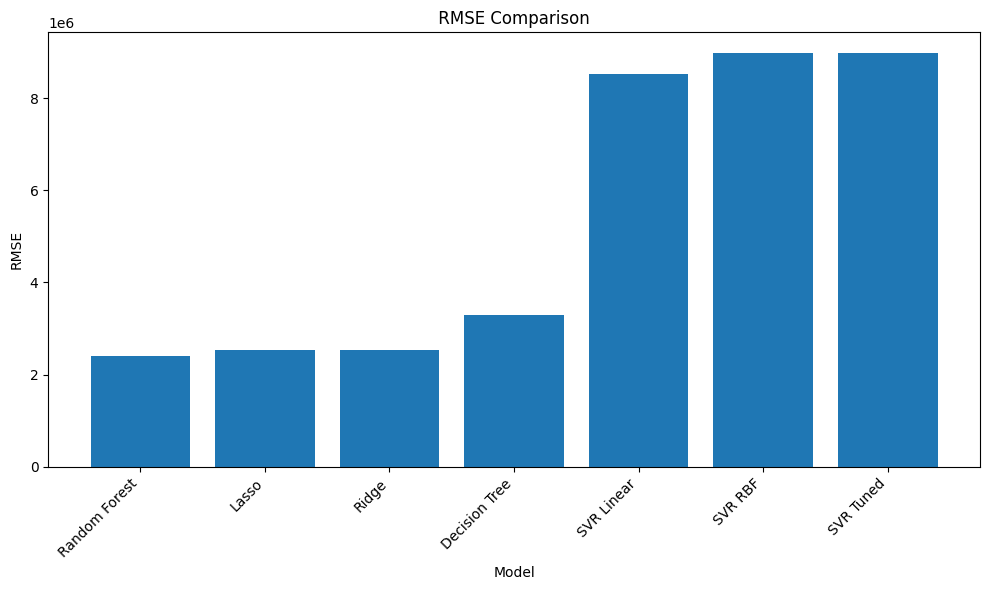

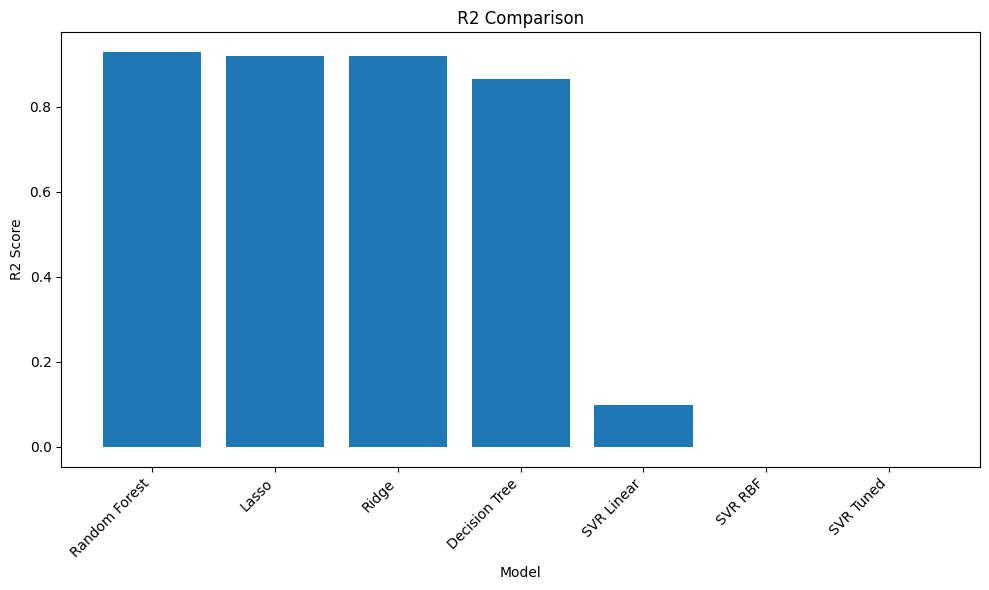

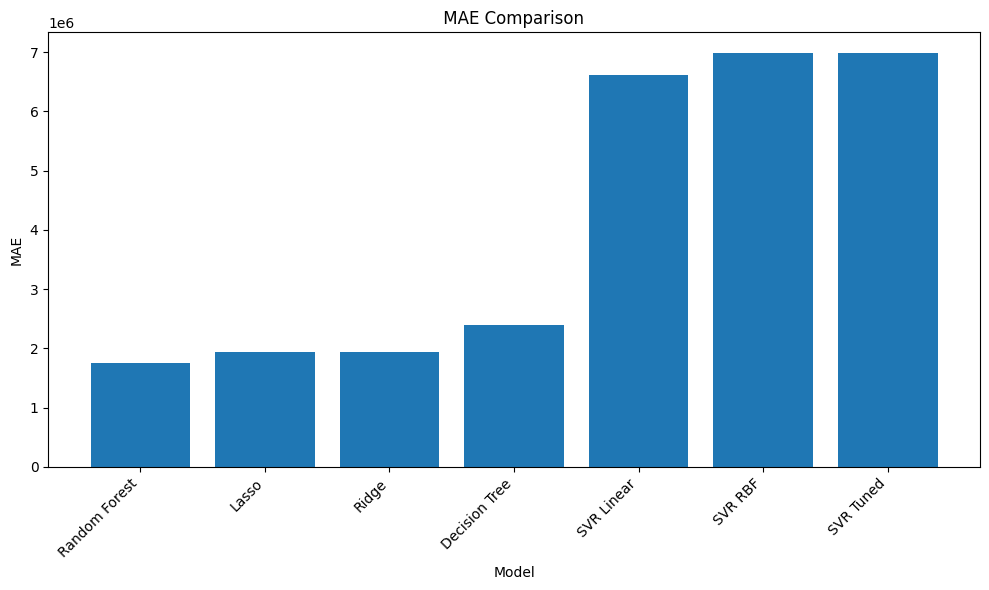

Task 25 -> Final Analysis & Report       DONE
Task 26 -> Evaluation Tables             DONE
Task 26 -> RMSE Plot                     DONE
Task 26 -> R2 Plot                       DONE
Task 26 -> MAE Plot                      DONE
Task 26 -> Final Conclusions             DONE

Files Created:
1. Part_H_Final_Model_Comparison.csv
2. Part_H_Overfitting_Analysis.csv
3. H_RMSE_Comparison.png
4. H_R2_Comparison.png
5. H_MAE_Comparison.png
6. Part_H_Final_Report.txt


In [21]:
# Part - H
# Final Analysis & Reporting


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#  Best Performig Model


best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(" \nBest Performig Model ")


print("Best Model:", best_model["Model"])
print("MSE:", best_model["MSE"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R2:", best_model["R2"])


#  Impact Of Regularization

regularized = comparison[
    comparison["Model"].isin(["Ridge", "Lasso"])
]

print(" \nImpact Of Regularization ")


print(regularized.to_string(index=False))

print("\nRidge and Lasso use regularization")
print("to reduce model complexity and control large coefficients.")


#  Cross-Validation Model Stability

print("\nCross-Validation Stability")


print(comparison)

print("\nCross-validation helps compare model")
print("performance across different data splits.")


# Linear Vs Non-Linear 


linear_models = comparison[
    comparison["Model"].isin([
        "Ridge",
        "Lasso",
        "SVR Linear"
    ])
]

non_linear_models = comparison[
    comparison["Model"].isin([
        "Decision Tree",
        "Random Forest",
        "SVR RBF",
        "SVR Tuned"
    ])
]


print(" \nLiner VS Non- Liner Models ")


print("\nLiner Models")
print(linear_models.to_string(index=False))

print("\nNon - Liner Models")
print(non_linear_models.to_string(index=False))


#  Business Interpretation


print(" \nBusiness Interpretation ")


print("""
1. Lower RMSE and MAE indicate lower prediction error.

2. Higher R2 indicates that the model explains more
   variation in the target variable.

3. Regularized models such as Ridge and Lasso
   help control model complexity.

4. Tree-based models can capture non-linear
   relationships between features and target.

5. SVR can model both linear and non-linear
   relationships depending on the kernel.

6. The model with the lowest test RMSE is selected
   as the best-performing model.
""")

# Final Model

final_table = comparison.copy()

final_table = final_table.sort_values(
    "RMSE"
)

print(" \n Final Model Ranking ")


print(
    final_table.to_string(
        index=False
    )
)


# Plot 1 - RMSE Comparison


plt.figure(figsize=(10, 6))

plt.bar(
    final_table["Model"],
    final_table["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title(" RMSE Comparison " )

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "H_RMSE_Comparison.png"
)

plt.show()



# Plot 2 - R2 Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_table["Model"],
    final_table["R2"]
)

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title(" R2 Comparison ")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "H_R2_Comparison.png"
)

plt.show()


# Plot 3 - MAE Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_table["Model"],
    final_table["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(" MAE Comparison ")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "H_MAE_Comparison.png"
)

plt.show()


# Save Final Evaluation 

final_table.to_csv(
    "Part_H_Final_Model_Comparison.csv",
    index=False
)


# Save Overfittring 

overfitting.to_csv(
    "Part_H_Overfitting_Analysis.csv",
    index=False
)


# Final Report

best_name = best_model["Model"]
best_rmse = best_model["RMSE"]
best_mae = best_model["MAE"]
best_r2 = best_model["R2"]


report = f"""

"""



# Save Report

with open(
    "Part_H_Final_Report.txt",
    "w"
) as file:

    file.write(report)


print("Task 25 -> Final Analysis & Report       DONE")
print("Task 26 -> Evaluation Tables             DONE")
print("Task 26 -> RMSE Plot                     DONE")
print("Task 26 -> R2 Plot                       DONE")
print("Task 26 -> MAE Plot                      DONE")
print("Task 26 -> Final Conclusions             DONE")

print("\nFiles Created:")
print("1. Part_H_Final_Model_Comparison.csv")
print("2. Part_H_Overfitting_Analysis.csv")
print("3. H_RMSE_Comparison.png")
print("4. H_R2_Comparison.png")
print("5. H_MAE_Comparison.png")
print("6. Part_H_Final_Report.txt")